<a href="https://colab.research.google.com/github/muzzamilmehmood28-ops/Devixo-AI-ML-Task01/blob/main/Devixoipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling for future plots
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('Dataset.csv')

# Verify successful load by checking shape
print(f"Dataset successfully loaded! Shape: {df.shape}")

Dataset successfully loaded! Shape: (8790, 10)


In [ ]:
display(df.sample(3, random_state=42))


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
3942,s5505,Movie,Kiss & Cry,Sean Cisterna,Canada,5/1/2017,2017,TV-MA,93 min,"Dramas, International Movies, Romantic Movies"
8360,s6264,TV Show,Beating Again,Not Given,South Korea,5/22/2017,2015,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman..."
221,s1463,TV Show,Running Man,Not Given,Pakistan,1/1/2021,2020,TV-Y7,1 Season,"Kids' TV, TV Comedies"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (8790, 10)


In [ ]:
# 1.6 Identify Column Types Programmatically
import pandas as pd
df = pd.read_csv('Dataset.csv')

# Automatically classify columns based on pandas dtypes and names
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
datetime_cols = [col for col in df.columns if 'date' in col.lower()]

print("--- Column Classification ---")
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)
print("Date/Time Columns (stored as strings/objects):", datetime_cols)

--- Column Classification ---
Numerical Columns: ['release_year']
Categorical Columns: ['show_id', 'type', 'title', 'director', 'country', 'date_added', 'rating', 'duration', 'listed_in']
Date/Time Columns (stored as strings/objects): ['date_added']


In [ ]:
# 2.1 Check missing values and placeholder strings
import pandas as pd

df = pd.read_csv('Dataset.csv')

# Check standard missing values (NaN)
print("Standard Missing Values (NaN):\n", df.isnull().sum())

# Check for hidden placeholder values in string columns
for col in df.select_dtypes(include=['object']).columns:
    not_given = (df[col] == 'Not Given').sum()
    unknown = (df[col].str.lower() == 'unknown').sum()
    if not_given > 0 or unknown > 0:
        print(f"Column '{col}': 'Not Given' = {not_given}, 'Unknown' = {unknown}")

Standard Missing Values (NaN):
 show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64
Column 'title': 'Not Given' = 0, 'Unknown' = 1
Column 'director': 'Not Given' = 2588, 'Unknown' = 0
Column 'country': 'Not Given' = 287, 'Unknown' = 0


In [ ]:
# 2.2 Handling Missing Values with Documented Justifications
import pandas as pd

df = pd.read_csv('Dataset.csv')

# 1. Inspecting missing values
print("Initial missing values check:\n", df.isnull().sum())

# 2. Removing Rows Justification:
# We drop the single record where title is 'Unknown' because an invalid title invalidates the entry.
df_clean = df[df['title'].str.lower() != 'unknown'].copy()
print(f"Rows removed due to invalid/missing critical title: {len(df) - len(df_clean)}")

# 3. Mode / Constant Imputation Justification:
# For 'director' and 'country', 'Not Given' acts as a missing placeholder.
# We replace 'Not Given' with 'Unknown Director' and 'Unknown Country' to preserve dataset size (8,789 rows)
# rather than dropping thousands of records.
df_clean['director'] = df_clean['director'].replace('Not Given', 'Unknown Director')
df_clean['country'] = df_clean['country'].replace('Not Given', 'Unknown Country')

# 4. Verifying that Forward/Backward fill or column dropping is not required:
# Explanation: ffill/bfill are skipped because rows are independent media records, not time-series sequences.
# Columns are retained because all 10 columns have 0% missing data after cleaning.

print("Missing values after cleaning handling:", df_clean.isnull().sum().sum())

Initial missing values check:
 show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64
Rows removed due to invalid/missing critical title: 1
Missing values after cleaning handling: 0


In [ ]:
# 2.3 Check and remove duplicate records
import pandas as pd

df = pd.read_csv('Dataset.csv')

# Count duplicate records across the entire dataframe
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate records found: {duplicate_count}")

# If duplicates exist, remove them
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates successfully removed.")
else:
    print("No duplicate records exist in this dataset.")

Number of duplicate records found: 0
No duplicate records exist in this dataset.


In [ ]:
# 2.4 Inspect and correct data types
print("Initial Data Types:\n", df.dtypes)

# Correction: Convert 'date_added' from object (string) to datetime format
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

print("\nCorrected Data Type for 'date_added':", df['date_added'].dtype)

Initial Data Types:
 show_id         object
type            object
title           object
director        object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
dtype: object

Corrected Data Type for 'date_added': datetime64[ns]


In [ ]:
# 2.5 Rename columns for clarity and consistency
df = df.rename(columns={
    'show_id': 'show_identifier',
    'type': 'content_type',
    'title': 'content_title',
    'director': 'director_name',
    'country': 'production_country',
    'date_added': 'date_added_to_platform',
    'release_year': 'specific_release_year',
    'rating': 'maturity_rating',
    'duration': 'content_duration',
    'listed_in': 'genres'
})

print("Updated Column Names:", df.columns.tolist())

Updated Column Names: ['show_identifier', 'content_type', 'content_title', 'director_name', 'production_country', 'date_added_to_platform', 'specific_release_year', 'maturity_rating', 'content_duration', 'genres']


In [ ]:
# 2.6 Check invalid values in numerical and categorical features
print("Minimum Release Year:", df['specific_release_year'].min())
print("Maximum Release Year:", df['specific_release_year'].max())

# Check for unexpected negative numbers or invalid ranges
invalid_years = df[df['specific_release_year'] < 1900]
print("Count of titles released before 1900:", len(invalid_years))

Minimum Release Year: 1925
Maximum Release Year: 2021
Count of titles released before 1900: 0


In [ ]:
# 2.7 Verify the cleaned dataset
print("--- CLEANED DATASET VERIFICATION ---")
print("1. Missing Values:\n", df.isnull().sum())
print("2. Duplicate Records Count:", df.duplicated().sum())
print("3. Final Dataset Shape:", df.shape)
print("\n4. Basic Statistics:")
display(df.describe())

--- CLEANED DATASET VERIFICATION ---
1. Missing Values:
 show_identifier           0
content_type              0
content_title             0
director_name             0
production_country        0
date_added_to_platform    0
specific_release_year     0
maturity_rating           0
content_duration          0
genres                    0
dtype: int64
2. Duplicate Records Count: 0
3. Final Dataset Shape: (8790, 10)

4. Basic Statistics:


,date_added_to_platform,specific_release_year
count,8790,8790.000000
mean,2019-05-17 21:44:01.638225408,2014.183163
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-03 00:00:00,2017.000000
75%,2020-08-19 18:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.825466


In [ ]:
# 3.1 Python Code for Descriptive Statistics
import pandas as pd

df = pd.read_csv('Dataset.csv')

# Display core descriptive statistics for numerical columns
print(df.describe())

       release_year
count   8790.000000
mean    2014.183163
std        8.825466
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


In [ ]:
# 3.2 Python Code: Mean
mean_release_year = df['release_year'].mean()
print(f"Calculated Mean Release Year: {mean_release_year:.4f}")

Calculated Mean Release Year: 2014.1832


In [ ]:
# 3.3 Python Code: Median
median_release_year = df['release_year'].median()
print(f"Calculated Median Release Year: {median_release_year}")

Calculated Median Release Year: 2017.0


In [ ]:
# 3.4 Python Code: Mode
mode_release_year = df['release_year'].mode().tolist()
print(f"Calculated Mode Release Year(s): {mode_release_year}")

Calculated Mode Release Year(s): [2018]


In [ ]:
# 3.5 Python Code: Standard Deviation and Variance
std_dev = df['release_year'].std()
variance = df['release_year'].var()

print(f"Calculated Standard Deviation: {std_dev:.4f}")
print(f"Calculated Variance: {variance:.4f}")

Calculated Standard Deviation: 8.8255
Calculated Variance: 77.8889


In [ ]:
# 3.6 Python Code for Correlation Analysis
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
print("Correlation Matrix:\n", corr_matrix)

Correlation Matrix:
               release_year
release_year           1.0


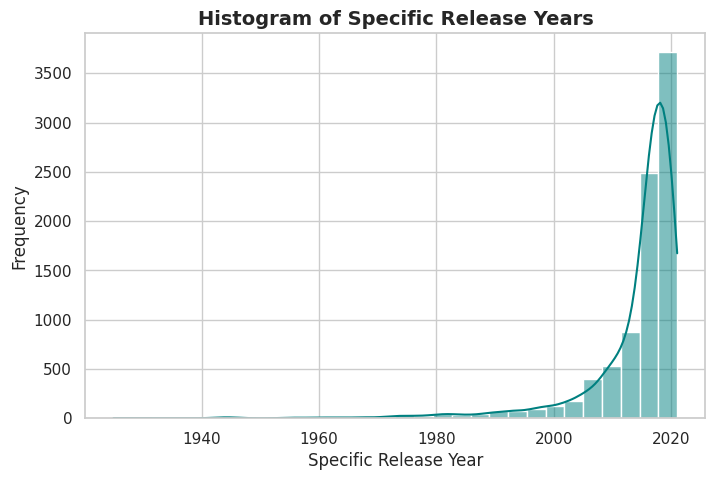

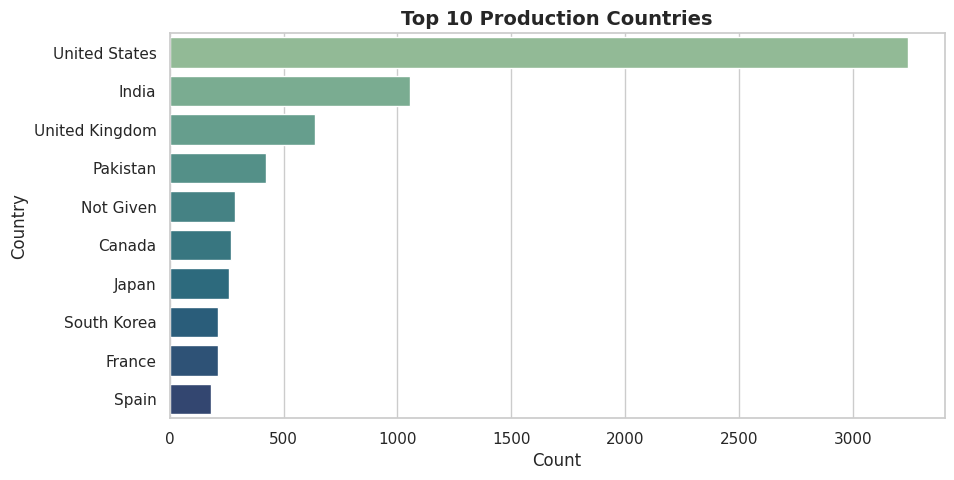

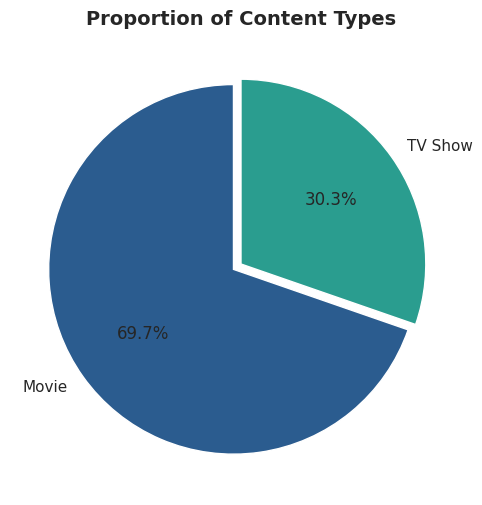

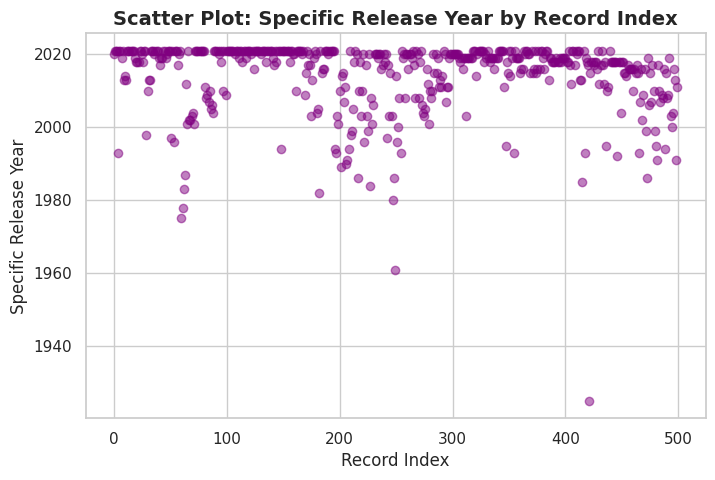

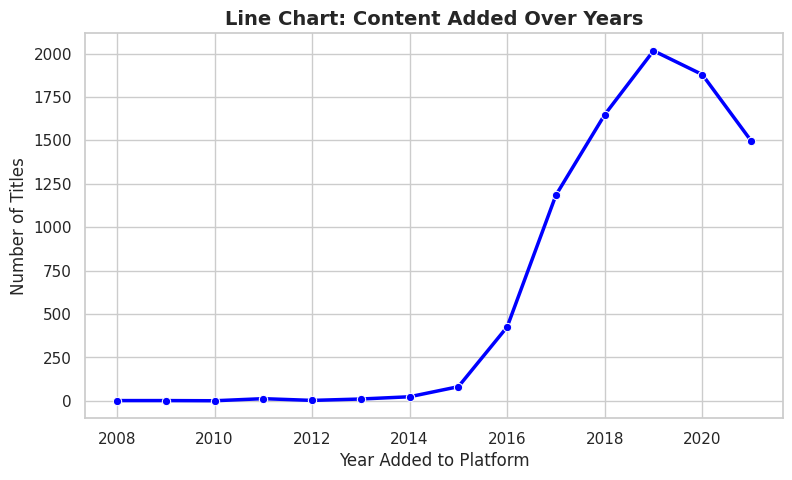

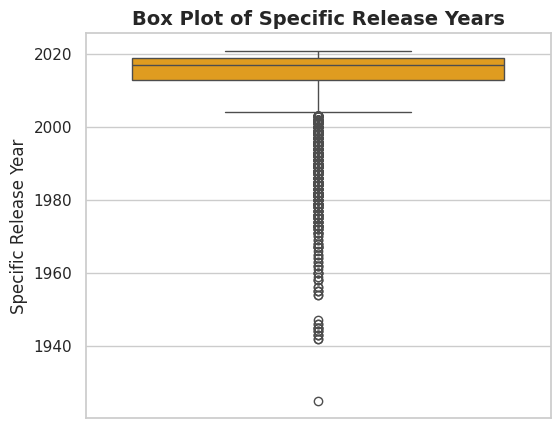

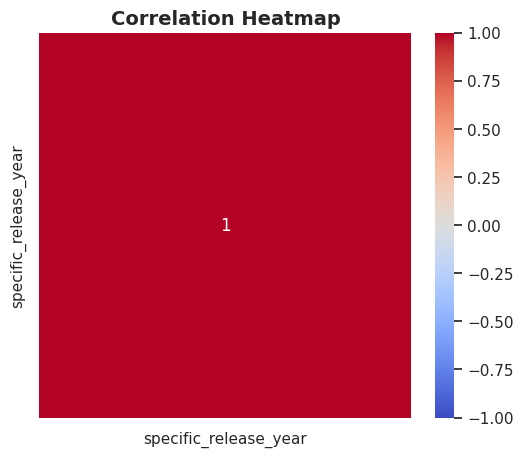

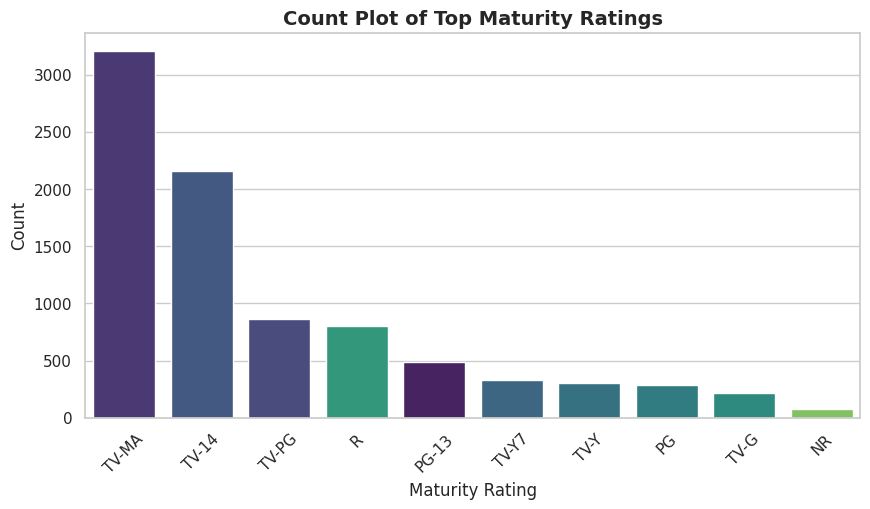

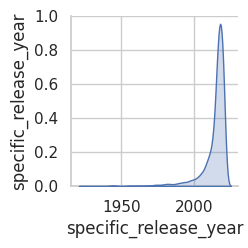

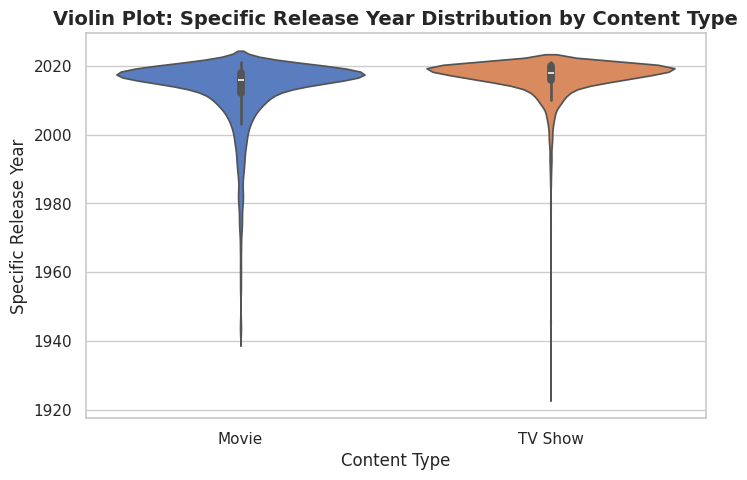

All 10 visualizations generated successfully


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Load dataset and rename column if necessary
df = pd.read_csv('Dataset.csv')
if 'release_year' in df.columns:
    df = df.rename(columns={'release_year': 'specific_release_year'})

# Create directory to store visualizations
os.makedirs('visualizations', exist_ok=True)

# 1. Histogram: Distribution of Specific Release Years
plt.figure(figsize=(8, 5))
sns.histplot(df['specific_release_year'], bins=30, kde=True, color='teal')
plt.title('Histogram of Specific Release Years', fontsize=14, fontweight='bold')
plt.xlabel('Specific Release Year', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.savefig('visualizations/1_histogram.png', bbox_inches='tight')
plt.show()
plt.close()

# 2. Bar Chart: Top 10 Production Countries
plt.figure(figsize=(10, 5))
top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='crest', legend=False)
plt.title('Top 10 Production Countries', fontsize=14, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.savefig('visualizations/2_barchart.png', bbox_inches='tight')
plt.show()
plt.close()

# 3. Pie Chart: Proportion of Content Types
plt.figure(figsize=(6, 6))
type_counts = df['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#2b5c8f', '#2a9d8f'], startangle=90, explode=(0.05, 0))
plt.title('Proportion of Content Types', fontsize=14, fontweight='bold')
plt.savefig('visualizations/3_piechart.png', bbox_inches='tight')
plt.show()
plt.close()

# 4. Scatter Plot: Specific Release Year vs Index
plt.figure(figsize=(8, 5))
plt.scatter(df.index[:500], df['specific_release_year'][:500], alpha=0.5, color='purple')
plt.title('Scatter Plot: Specific Release Year by Record Index', fontsize=14, fontweight='bold')
plt.xlabel('Record Index', fontsize=12)
plt.ylabel('Specific Release Year', fontsize=12)
plt.savefig('visualizations/4_scatterplot.png', bbox_inches='tight')
plt.show()
plt.close()

# 5. Line Chart: Content Added Over Years
df['year_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce').dt.year
yearly_added = df['year_added'].value_counts().sort_index()
plt.figure(figsize=(9, 5))
sns.lineplot(x=yearly_added.index, y=yearly_added.values, marker='o', color='blue', linewidth=2.5)
plt.title('Line Chart: Content Added Over Years', fontsize=14, fontweight='bold')
plt.xlabel('Year Added to Platform', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.savefig('visualizations/5_linechart.png', bbox_inches='tight')
plt.show()
plt.close()

# 6. Box Plot: Specific Release Year Dispersion and Outliers
plt.figure(figsize=(6, 5))
sns.boxplot(y=df['specific_release_year'], color='orange')
plt.title('Box Plot of Specific Release Years', fontsize=14, fontweight='bold')
plt.ylabel('Specific Release Year', fontsize=12)
plt.savefig('visualizations/6_boxplot.png', bbox_inches='tight')
plt.show()
plt.close()

# 7. Correlation Heatmap
plt.figure(figsize=(6, 5))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.savefig('visualizations/7_heatmap.png', bbox_inches='tight')
plt.show()
plt.close()

# 8. Count Plot: Maturity Ratings
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index[:10], hue='rating', palette='viridis', legend=False)
plt.title('Count Plot of Top Maturity Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Maturity Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.savefig('visualizations/8_countplot.png', bbox_inches='tight')
plt.show()
plt.close()

# 9. Pair Plot
sns.pairplot(numeric_df[['specific_release_year']], diag_kind='kde')
plt.savefig('visualizations/9_pairplot.png', bbox_inches='tight')
plt.show()
plt.close()

# 10. Violin Plot: Specific Release Year Distribution by Type
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='type', y='specific_release_year', hue='type', palette='muted', legend=False)
plt.title('Violin Plot: Specific Release Year Distribution by Content Type', fontsize=14, fontweight='bold')
plt.xlabel('Content Type', fontsize=12)
plt.ylabel('Specific Release Year', fontsize=12)
plt.savefig('visualizations/10_violinplot.png', bbox_inches='tight')
plt.show()
plt.close()

print("All 10 visualizations generated successfully")